Hybrid: CNN + Attention

In [ ]:
# Mount Google Drive to access datasets, models, or other files stored in the user's Drive.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import all requried libraries.

import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_squared_error, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Connect to OCT dataset folder in Drive.

dataset_path = '/content/drive/My Drive/OCT_Dataset'

In [ ]:
# Initialise ImageDataGenerator with comprehensive augmentation and preprocessing:

data_gen = ImageDataGenerator(

    rescale=1./255, # Normalizes pixel values from [0, 255] to [0, 1] to improve model convergence.


    validation_split=0.2, # Reserves 20% of the data for validation.

    # Geometric augmentations:
    rotation_range=20, # Random rotations (±20 degrees)
    width_shift_range=0.2, # Horizontal shifts (±20% of width)
    height_shift_range=0.2, # Vertical shifts (±20% of height)
    shear_range=0.2, # Shear transformations (20% intensity)
    zoom_range=0.2, # Random zoom [80%-120%]

    # Flipping augmentation:
    # Random left-right flips
    horizontal_flip=True,

    # Pixel filling strategy:
    fill_mode='nearest' # Fill new pixels with nearest existing values.
)

In [ ]:
# Prepare the training dataset using the data generator.
# Images are resized to 128x128 pixels, loaded in batches of 32, and labels are one-hot encoded. Only the 'training' subset is loaded.

train_data = data_gen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 623 images belonging to 3 classes.


In [ ]:
# Initialise validation data generator:
# - Uses same ImageDataGenerator configuration (ensures consistent preprocessing).

# - Critical settings for proper evaluation:

val_data = data_gen.flow_from_directory(
    # Dataset specifications:
    dataset_path, # Path to main dataset folder.
    target_size=(128, 128), # Resizes images to 128x128 (matches model input).
    batch_size=32, # Standard batch size for evaluation.

    # Label handling:
    class_mode='categorical', # For multi-class classification.

    # Validation-specific settings:
    subset='validation',  # Uses natural folder-based class ordering.
    shuffle=False  # Preserves sample order for correct evaluation.
)

Found 155 images belonging to 3 classes.


In [ ]:
# Define a custom attention block that adaptively weights the input feature maps.
# This block helps the model focus on the most relevant features.

def attention_block(inputs):
    x = layers.Conv2D(64, (1, 1), activation='relu')(inputs) # Channel-wise feature transformation.

    x = layers.GlobalAveragePooling2D()(x) # Global context encoding.

    x = layers.Dense(64, activation='relu')(x) # Dense transformation.

    x = layers.Dense(inputs.shape[-1], activation='sigmoid')(x) # Output attention weights.

    return layers.Multiply()([inputs, x]) # Apply attention to input feature maps.

In [ ]:
# Define the input layer with the shape matching the dataset (128x128 RGB images).

input_layer = layers.Input(shape=(128, 128, 3))

# Convolutional block 1 - Initial feature extraction.
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = layers.MaxPooling2D((2, 2))(x)
x = attention_block(x) # Apply attention

# Convolutional block 2
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = attention_block(x) # Apply attention

# Convolutional block 3
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = attention_block(x) # Apply attention

# Flatten and add fully connected layers
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Dropout for regularization

# Output layer with softmax activation for multi-class classification (3 classes: AMD/DME/Normal).
output_layer = layers.Dense(3, activation='softmax')(x)

# Create the final model by specifying the input and output layers.
model = models.Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# Define an optimizer with a fixed initial learning rate.
optimizer = optimizers.Adam(learning_rate=0.001)

# Define a learning rate schedule: reduces the learning rate by 5% after each epoch.
lr_schedule = callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 0.95**epoch)

In [ ]:
# Compile the model with categorical crossentropy loss (for multi-class classification) and accuracy as the evaluation metric.

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture summary.
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 32)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 64)     │          2,112 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 64)             │              0 │ conv2d_1[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 64)             │          4,160 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32)             │          2,080 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 64, 64, 32)     │              0 │ max_pooling2d[0][0],   │
│                           │                        │                │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 64)     │         18,496 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 64)     │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 64)     │          4,160 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 64)             │              0 │ conv2d_3[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          4,160 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 64)             │          4,160 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 32, 32, 64)     │              0 │ max_pooling2d_1[0][0], │
│                           │                        │                │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 128)    │         73,856 │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2      

 Total params: 8,524,451 (32.52 MB)

 Trainable params: 8,524,451 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define early stopping to prevent overfitting.
# Training will stop if validation performance does not improve for 5 consecutive epochs.
# The model will restore the weights from the epoch with the best validation accuracy.

early_stopping = callbacks.EarlyStopping(patience=5, restore_best_weights=True)


# Train the model using the training and validation datasets.
# Increased from 10 epochs in Hybrid_v1 to 20 epochs, but may stop early if no improvement is detected.
# The early stopping callback is used to monitor validation performance.

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stopping]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 163s 6s/step - accuracy: 0.4317 - loss: 1.0329 - val_accuracy: 0.4452 - val_loss: 0.9983
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5277 - loss: 0.9907 - val_accuracy: 0.6129 - val_loss: 0.9750
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5056 - loss: 0.9673 - val_accuracy: 0.5484 - val_loss: 0.9223
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.6076 - loss: 0.8988 - val_accuracy: 0.6581 - val_loss: 0.8286
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5891 - loss: 0.8914 - val_accuracy: 0.6581 - val_loss: 0.8371
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5951 - loss: 0.8843 - val_accuracy: 0.6129 - val_loss: 0.8451
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.5945 - loss: 0.8489 - val_accuracy: 0.5935 - val_loss: 0.8555
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6634 - loss: 0.8033 - val_accuracy: 0.6387 - val_loss: 0.7899
Ep

In [ ]:
# Generate predictions on the validation dataset.
# 'predict' returns class probabilities; we take the class with the highest probability.

val_preds = model.predict(val_data)
val_preds_classes = np.argmax(val_preds, axis=-1)

# Retrieve true class labels from the validation generator.
val_labels = val_data.classes

# Get the class names (from folder structure used during ImageDataGenerator setup).
class_names = list(val_data.class_indices.keys())

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 668ms/step


In [ ]:
# Generate a classification report with precision, recall, F1-score, and accuracy.
# The report is returned as a dictionary for easier programmatic access.

report = classification_report(val_labels, val_preds_classes, target_names=class_names, output_dict=True)

# Extract overall accuracy.
accuracy = report['accuracy']

# Extract precision, recall, and F1-score per class.
precision = {cls: report[cls]['precision'] for cls in class_names}
recall = {cls: report[cls]['recall'] for cls in class_names}
f1_score = {cls: report[cls]['f1-score'] for cls in class_names}

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Display the evaluation results.

print("\nPerformance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
for cls in class_names:
    print(f"Class '{cls}' - Precision: {precision[cls]:.2f}, Recall: {recall[cls]:.2f}, F1-Score: {f1_score[cls]:.2f}")


Performance Metrics:
Accuracy: 0.7226
Class 'AMD' - Precision: 0.6667, Recall: 0.8116, F1-Score: 0.7320
Class 'DME' - Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Class 'NO' - Precision: 0.7887, Recall: 0.8485, F1-Score: 0.8175


In [ ]:
# Format the performance metrics into a table.

performance_data = {
    "Metric": ["Accuracy", "Mean Squared Error (MSE)", "Area Under the ROC Curve (AUC)"],
    "Value": [round(accuracy, 2), round(mse, 2), round(auc, 2)]
}

performance_table = pd.DataFrame(performance_data)

# Print the overall performance metrics table.

print("\nOverall Performance Metrics:")
print(performance_table.to_string(index=False))


Overall Performance Metrics:
                        Metric  Value
                      Accuracy   0.72
      Mean Squared Error (MSE)   0.72
Area Under the ROC Curve (AUC)   0.85


In [ ]:
# Format the class-wise metrics into a table.

class_wise_metrics = {
    "Class": class_names,
    "Precision": [round(precision[cls], 2) for cls in class_names],
    "Recall": [round(recall[cls], 2) for cls in class_names],
    "F1-Score": [round(f1_score[cls], 2) for cls in class_names]
}

class_metrics_table = pd.DataFrame(class_wise_metrics)

# Print the class-wise performance metrics table.

print("\nClass-wise Performance Metrics:")
print(class_metrics_table.to_string(index=False))


Class-wise Performance Metrics:
Class  Precision  Recall  F1-Score
  AMD       0.67    0.81      0.73
  DME       0.00    0.00      0.00
   NO       0.79    0.85      0.82


In [ ]:
# Mean Squared Error (MSE)
mse = mean_squared_error(val_labels, val_preds_classes)
print(f"\nMean Squared Error (MSE): {mse:.2f}")


Mean Squared Error (MSE): 0.7226


In [ ]:
# Calculate the Area Under the ROC Curve (AUC) for model evaluation.
# Supports both binary and multi-class classification settings.

if len(class_names) == 2:  # Binary classification
    # For binary, use the probability of the positive class.
    auc = roc_auc_score(val_labels, val_preds[:, 1])

else:  # Multi-class classification (one-vs-all approach)
    # Convert labels to one-hot encoding and compute macro AUC.
    auc = roc_auc_score(tf.keras.utils.to_categorical(val_labels, num_classes=len(class_names)), val_preds, multi_class='ovr')

# Print the overall AUC score
print(f"Area Under the ROC Curve (AUC): {auc:.2f}")

Area Under the ROC Curve (AUC): 0.8543


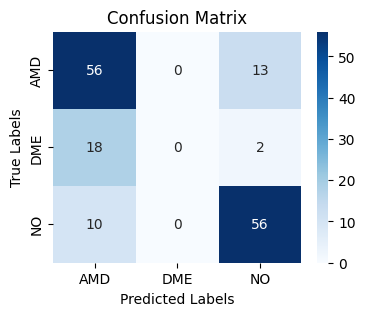

In [ ]:
# Generate and plot the confusion matrix to visualise classification performance

conf_matrix = confusion_matrix(val_labels, val_preds_classes)
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

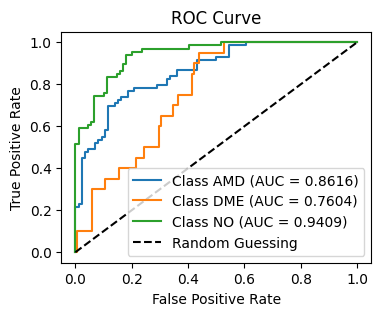

In [ ]:
# Plot ROC curves for each class in multi-class setting
plt.figure(figsize=(4, 3))

for i, cls in enumerate(class_names):
    # Compute false positive rate and true positive rate for each class
    fpr, tpr, _ = roc_curve(
        tf.keras.utils.to_categorical(val_labels, num_classes=len(class_names))[:, i],
        val_preds[:, i])

    # Plot ROC curve with individual class AUC
    plt.plot(
        fpr,
        tpr,
        label=f"Class {cls} (AUC = {roc_auc_score(tf.keras.utils.to_categorical(val_labels, num_classes=len(class_names))[:, i], val_preds[:, i]):.2f})")

# Plot the diagonal line representing random guessing
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

# Final ROC plot formatting
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()